## 数值稳定性

### 神经网络的梯度

- 考虑如下有 $d$ 层的神经网络

$$
\mathbf{h}^t = f_t(\mathbf{h}^{t-1}) \quad \text{and} \quad y = \ell \circ f_d \circ \cdots \circ f_1(\mathbf{x})
$$

- 计算损失 $\ell$ 关于参数 $\mathbf{W}_t$ 的梯度

$$
\frac{\partial \ell}{\partial \mathbf{W}^t} = \frac{\partial \ell}{\partial \mathbf{h}^d} \frac{\partial \mathbf{h}^d}{\partial \mathbf{h}^{d-1}} \cdots \frac{\partial \mathbf{h}^{t+1}}{\partial \mathbf{h}^t} \frac{\partial \mathbf{h}^t}{\partial \mathbf{W}^t}
$$

- 计算中存在d-t次矩阵乘法 -出现问题

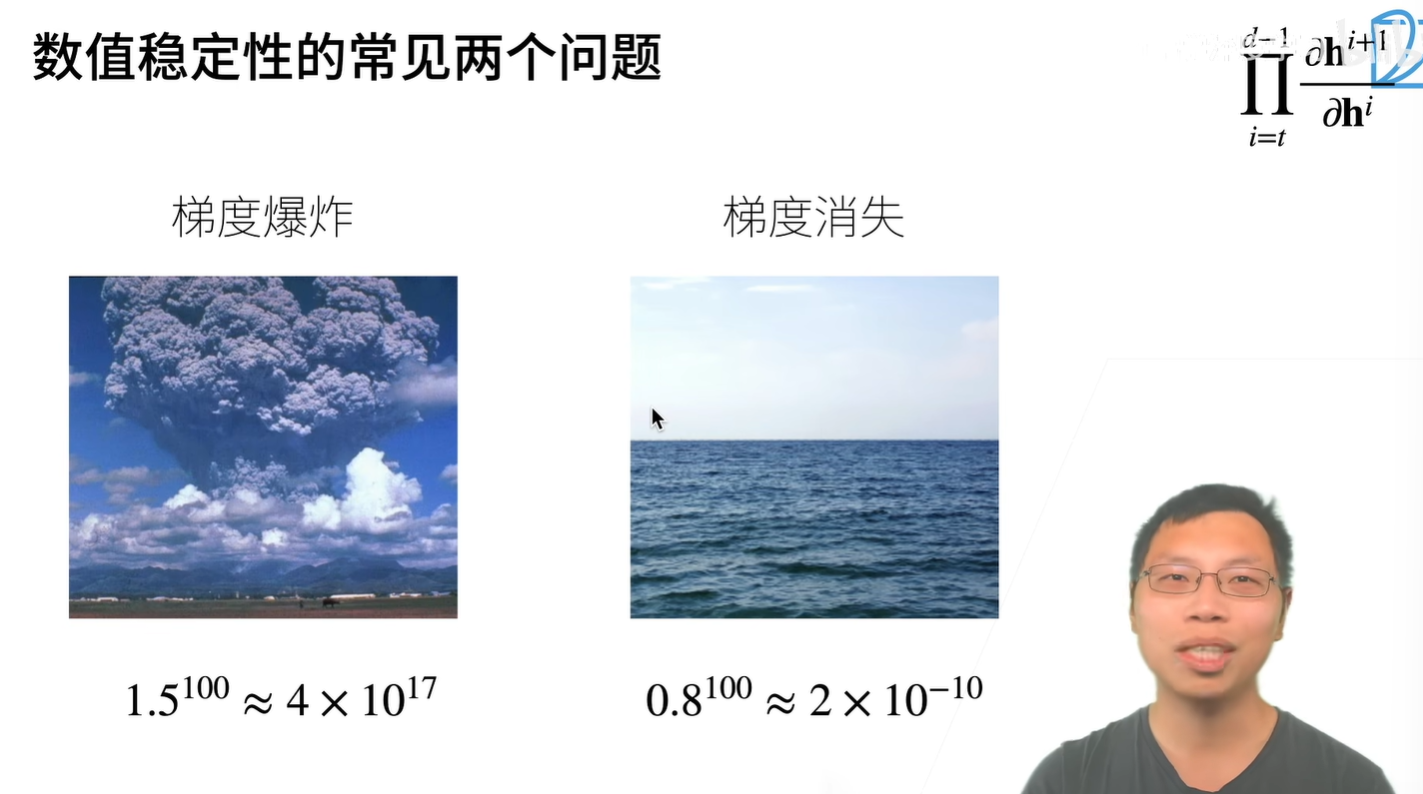

### 例子：MLP

- 加入如下 MLP（为了简单省略了偏移）

$$
f_t(\mathbf{h}^{t-1}) = \sigma(\mathbf{W}^t \mathbf{h}^{t-1}) \quad \sigma \text{是激活函数}
$$

$$
\frac{\partial \mathbf{h}^t}{\partial \mathbf{h}^{t-1}} = \operatorname{diag}\left(\sigma'(\mathbf{W}^t \mathbf{h}^{t-1})\right) (\mathbf{W}^t)^\mathrm{T} \quad \sigma' \text{是} \sigma \text{的导数函数}
$$

$$
\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \prod_{i=t}^{d-1} \operatorname{diag}\left(\sigma'(\mathbf{W}^i \mathbf{h}^{i-1})\right) (\mathbf{W}^i)^\mathrm{T}
$$

### 梯度爆炸

- 使用 ReLU 作为激活函数

$$
\sigma(x) = \max(0, x) \quad \text{and} \quad \sigma'(x) = 
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{otherwise}
\end{cases}
$$

- 
$$
\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \prod_{i=t}^{d-1} \operatorname{diag}\left(\sigma'(\mathbf{W}^i \mathbf{h}^{i-1})\right) (\mathbf{W}^i)^\mathrm{T}
$$
  的一些元素会来自于 $\prod_{i=t}^{d-1} (\mathbf{W}^i)^\mathrm{T}$

- 如果 $d-t$ 很大，值将会很大

### 梯度爆炸的问题

- 值超出值域（infinity）
    - 对于16位浮点数尤为严重（数值区间 6e-5 ~ 6e4）

- 对学习率敏感
    - 如果学习率太大 → 大参数值 → 更大的梯度
    - 如果学习率太小 → 训练无进展
    - 我们可能需要在训练过程中不断调整学习率

### 梯度消失

- 使用 sigmoid 作为激活函数

$$
\sigma(x) = \frac{1}{1 + e^{-x}} \qquad \sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

- 当输入较大或较小时，梯度趋于零，导致小梯度问题

- 
$$
\prod_{i=t}^{d-1} \frac{\partial \mathbf{h}^{i+1}}{\partial \mathbf{h}^i} = \prod_{i=t}^{d-1} \operatorname{diag}\left(\sigma'(\mathbf{W}^i \mathbf{h}^{i-1})\right) (\mathbf{W}^i)^\mathrm{T}
$$
  的元素值是 $d-t$ 个小数值的乘积

- 数值的乘积

$$
0.8^{100} \approx 2 \times 10^{-10}
$$

### 梯度消失的问题

- 梯度值变成 0
    - 对 16 位浮点数尤为严重
- 训练没有进展
    - 不管如何选择学习率
- 对于底部层尤为严重
    - 仅仅顶部层训练的较好
    - 无法让神经网络更深

### 总结
- 当数值过大或数值过小时会导致数值问题
- 常发生在深度模型中，因为其会对n个数累乘

### 让训练更加稳定

- 目标：让梯度值在合理的范围内
    - 例如 $[1e^{-6}, 1e^{3}]$
- 将乘法变加法
    - ResNet, LSTM
- 归一化
    - 梯度归一化，梯度裁剪
- 合理的权重初始化和激活函数


### 让每层的方差是一个常数

- 将每层的输出和梯度都看做随机变量
- 让它们的均值和方差都保持一致

正向：
$$
\mathbb{E}[h_i^t] = 0 \\
\operatorname{Var}[h_i^t] = a
$$

反向：
$$
\mathbb{E}\left[\frac{\partial \ell}{\partial h_i^t}\right] = 0 \\
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_i^t}\right] = b \quad \forall i, t
$$

a 和 b 都是常数

### 合理的权重初始化
- 在合理值区间里随机初始化参数
- 训练开始的时候更容易有数值不稳定
    - 远离最优解的地方损失函数数值表面可能很复杂
    - 最优解附近表面会比较平
- 使用 $\mathcal{N}(0, 0.01)$ 来初始化可能对小网络没问题，但不能保证深度神经网络

### 例子：MLP

- 假设
    - $w_{i,j}^t$ 是 i.i.d，那么 $\mathbb{E}[w_{i,j}^t] = 0,\ \operatorname{Var}[w_{i,j}^t] = \gamma_t$
    - $h_i^{t-1}$ 独立于 $w_{i,j}^t$
- 假设没有激活函数 $\mathbf{h}^t = \mathbf{W}^t \mathbf{h}^{t-1}$，这里 $\mathbf{W}^t \in \mathbb{R}^{n_t \times n_{t-1}}$

$$
\mathbb{E}[h_i^t] = \mathbb{E}\left[\sum_j w_{i,j}^t h_j^{t-1}\right] = \sum_j \mathbb{E}[w_{i,j}^t] \mathbb{E}[h_j^{t-1}] = 0
$$

### 正向方差

$$
\operatorname{Var}[h_i^t] = \mathbb{E}\left((h_i^t)^2\right) - \mathbb{E}[h_i^t]^2 = \mathbb{E}\left[\left(\sum_j w_{i,j}^t h_j^{t-1}\right)^2\right]
$$

$$
= \mathbb{E}\left[\sum_j (w_{i,j}^t)^2 (h_j^{t-1})^2 + \sum_{j \neq k} w_{i,j}^t w_{i,k}^t h_j^{t-1} h_k^{t-1}\right]
$$

$$
= \sum_j \mathbb{E}\left[(w_{i,j}^t)^2\right] \mathbb{E}\left[(h_j^{t-1})^2\right]
$$

$$
= \sum_j \operatorname{Var}[w_{i,j}^t] \operatorname{Var}[h_j^{t-1}] = n_{t-1} \gamma_t \operatorname{Var}[h_j^{t-1}]
$$

$$
n_{t-1} \gamma_t = 1
$$


### 反向均值和方差

- 跟正向情况类似

$$
\frac{\partial \ell}{\partial \mathbf{h}^{t-1}} = \frac{\partial \ell}{\partial \mathbf{h}^t} \mathbf{W}^t
$$

$$
\left(\frac{\partial \ell}{\partial \mathbf{h}^{t-1}}\right)^\mathrm{T} = (\mathbf{W}^t)^\mathrm{T} \left(\frac{\partial \ell}{\partial \mathbf{h}^t}\right)^\mathrm{T}
$$

$$
\mathbb{E}\left[\frac{\partial \ell}{\partial h_i^{t-1}}\right] = 0
$$

$$
\operatorname{Var}\left[\frac{\partial \ell}{\partial h_i^{t-1}}\right] = n_t \gamma_t \operatorname{Var}\left[\frac{\partial \ell}{\partial h_j^t}\right]
$$

$$
n_t \gamma_t = 1
$$

### Xavier 初始化

- 难以需要满足 $n_{t-1}\gamma_t = 1$ 和 $n_t\gamma_t = 1$
- Xavier 使得 $\gamma_t(n_{t-1} + n_t)/2 = 1 \rightarrow \gamma_t = 2/(n_{t-1} + n_t)$
    - 正态分布 $\mathcal{N}\left(0, \sqrt{2/(n_{t-1} + n_t)}\right)$
    - 均匀分布 $\mathcal{U}\left(-\sqrt{6/(n_{t-1} + n_t)}, \sqrt{6/(n_{t-1} + n_t)}\right)$
        - 分布 $\mathcal{U}[-a, a]$ 和方差是 $a^2/3$
- 适配权重形状变换，特别是 $n_t$


### 总结
- 合理的权重初始值和激活函数的选取可以提升数值稳定性